In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Data Understanding

In [2]:
df = pd.read_excel("premium_senior.xlsx")

df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


In [3]:
df.shape

(29886, 13)

In [4]:
df["age"].min()

26

In [5]:
print(f"Rows:- {df.shape[0]} \nColumns:- {df.shape[1]}")

Rows:- 29886 
Columns:- 13


In [6]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

# Data Cleaning 

### Looking for Null Values 

In [7]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [8]:
df.dropna(inplace=True)

df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29886.000000,29886.000000,29886.000000,29886.000000
mean,43.396105,2.385933,23.364184,20892.303821
std,13.412657,1.421137,24.740339,6936.813440
min,26.000000,0.000000,1.000000,3625.000000
25%,34.000000,1.000000,7.000000,15697.250000
50%,42.000000,3.000000,17.000000,20489.000000
75%,52.000000,3.000000,32.000000,26360.000000
max,356.000000,5.000000,930.000000,43471.000000


Min Number of dependent is negative ,max age is 356 , max income is 930 

In [12]:
df[df.number_of_dependants<0].shape[0]

0

In [13]:
df[df.number_of_dependants<0]["number_of_dependants"].unique()

array([], dtype=int64)

Converting this to Positive Value 

In [14]:
df["number_of_dependants"] = df["number_of_dependants"].abs()

df["number_of_dependants"].describe()

count    29886.000000
mean         2.385933
std          1.421137
min          0.000000
25%          1.000000
50%          3.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

### Finding Outliers using Boxplot

In [15]:
df.skew(numeric_only=True)

age                      5.743064
number_of_dependants    -0.227200
income_lakhs             6.675184
annual_premium_amount    0.143180
dtype: float64

In [16]:
df.kurt(numeric_only=True)

age                      108.229072
number_of_dependants      -0.777960
income_lakhs             177.404225
annual_premium_amount     -0.772120
dtype: float64

There are Many Outliers in our dataset ( specially in age and income column ) which we have to deal with 

In [17]:
df.dtypes

age                       int64
gender                   object
region                   object
marital_status           object
number_of_dependants      int64
bmi_category             object
smoking_status           object
employment_status        object
income_level             object
income_lakhs              int64
medical_history          object
insurance_plan           object
annual_premium_amount     int64
dtype: object

In [18]:
numerical_columns= df.select_dtypes(["int64"]).columns

numerical_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

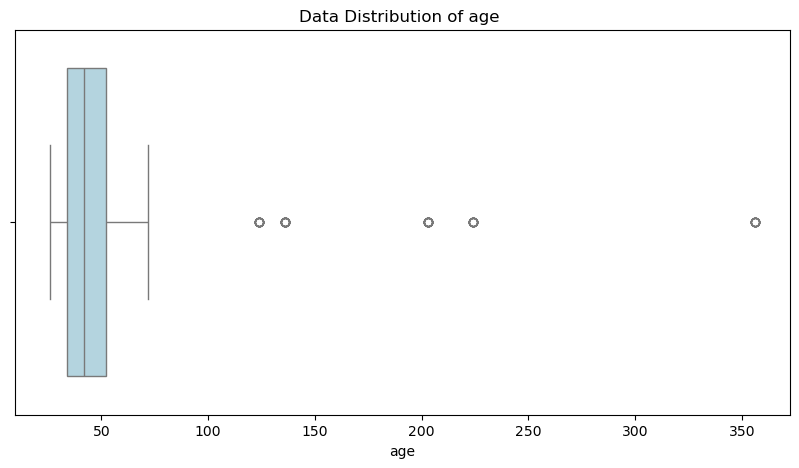

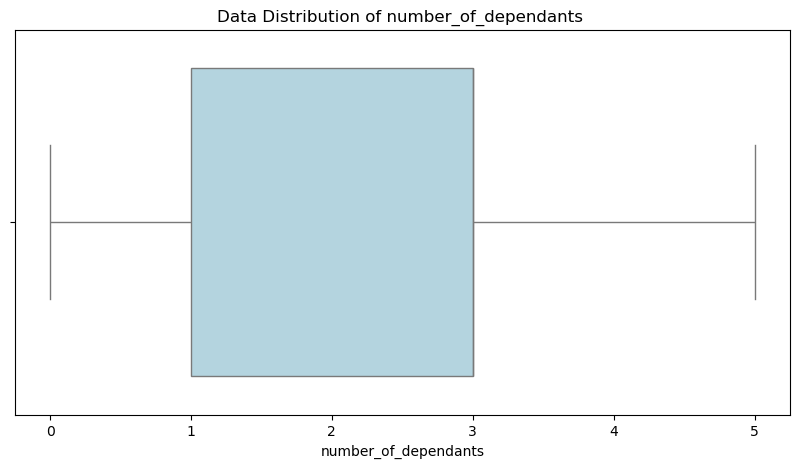

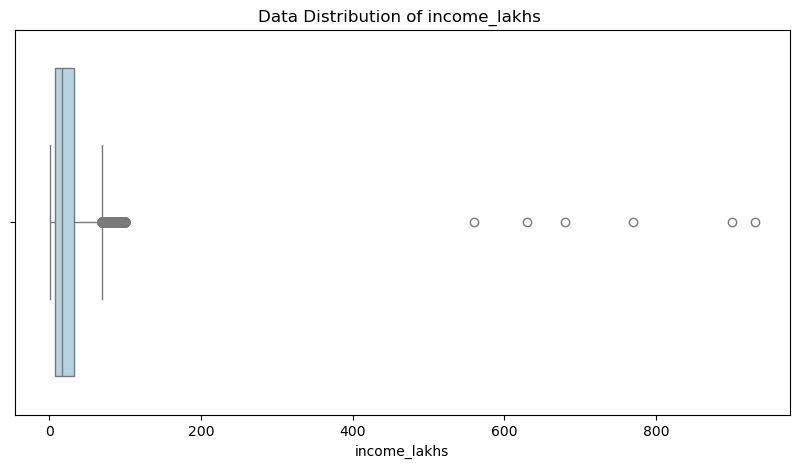

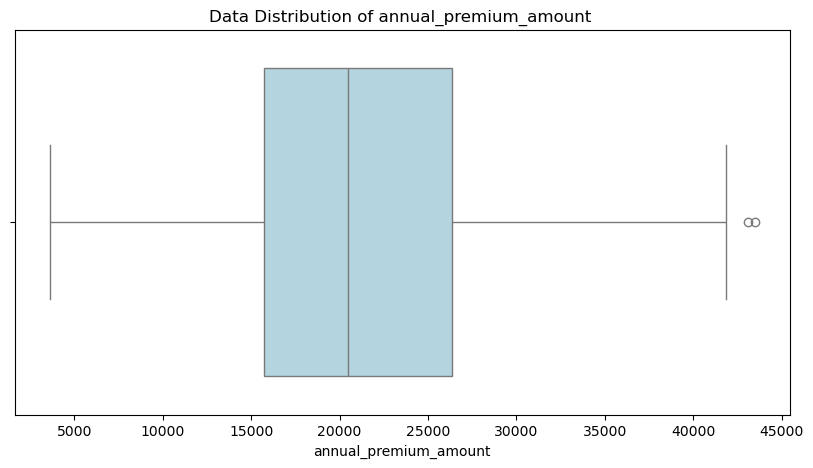

In [19]:
for i in numerical_columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[i],color='lightblue')
    plt.title(f"Data Distribution of {i} ")

plt.show()

Here Age and Income have significant numbers of outliers

In [20]:
df[(df.age>100)]["age"].count()

np.int64(58)

In [21]:
df[df.age<18]["age"].count()

np.int64(0)

In [22]:
df[(df.age>100) & (df.age>=18)]["age"].unique()

array([224, 124, 136, 203, 356])

In [23]:
df_1 = df[(df.age<=100) & (df.age>=18)].copy()

df_1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29828.000000,29828.000000,29828.000000,29828.000000
mean,43.095380,2.387790,23.371530,20901.900563
std,11.041991,1.420641,24.751262,6928.457636
min,26.000000,0.000000,1.000000,6538.000000
25%,34.000000,1.000000,7.000000,15706.000000
50%,42.000000,3.000000,17.000000,20496.000000
75%,52.000000,3.000000,32.000000,26361.000000
max,72.000000,5.000000,930.000000,43471.000000


For Income we can use Quantile to Remove Extreme Outliers

<Axes: xlabel='income_lakhs', ylabel='Count'>

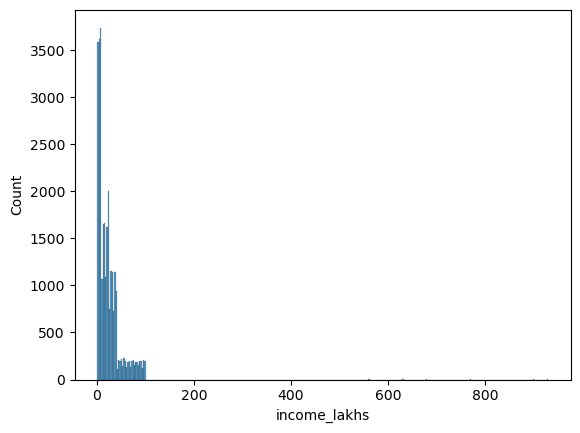

In [24]:
sns.histplot(df["income_lakhs"])

In [25]:
def get_iqr_boundary(col):
    q1 , q3 = col.quantile([0.25,0.75])
    IQR = q3-q1
    lower = q1 - 1.5*IQR
    upper = q3 + 1.5*IQR
    return lower , upper 

In [26]:
get_iqr_boundary(df_1.income_lakhs)

(-30.5, 69.5)

In [27]:
df_1[df_1.income_lakhs>55]["income_lakhs"].count()

np.int64(3013)

Since there are almost 5k people with more than Q3 income level we cant drop them. Lets just do trial and error and find the real outlier zone 

In [28]:
df_1.income_lakhs.quantile(0.95)

np.float64(78.0)

In [29]:
df[df.income_lakhs>77]["income_lakhs"].count()

np.int64(1529)

This is also too much to call outliers 

In [30]:
df_1.income_lakhs.quantile(0.99)

np.float64(96.0)

In [31]:
df[df.income_lakhs>96]["income_lakhs"].count()

np.int64(286)

Still Cant drop 

In [32]:
df_1.income_lakhs.quantile(0.999)

np.float64(100.0)

In [33]:
df[df.income_lakhs>100]["income_lakhs"].count()

np.int64(6)

In [34]:
income_threshold = df_1.income_lakhs.quantile(0.999)

In [35]:
df_2 = df_1[df_1.income_lakhs<=income_threshold].copy()

df_2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29822.000000,29822.000000,29822.000000,29822.000000
mean,43.094896,2.387734,23.226343,20900.689223
std,11.042430,1.420644,22.455408,6928.192115
min,26.000000,0.000000,1.000000,6538.000000
25%,34.000000,1.000000,7.000000,15705.250000
50%,42.000000,3.000000,17.000000,20495.500000
75%,52.000000,3.000000,32.000000,26360.000000
max,72.000000,5.000000,100.000000,43471.000000


In [36]:
df_2.shape

(29822, 13)

# Exploratory Data Analysis 

### Univariate Analysis

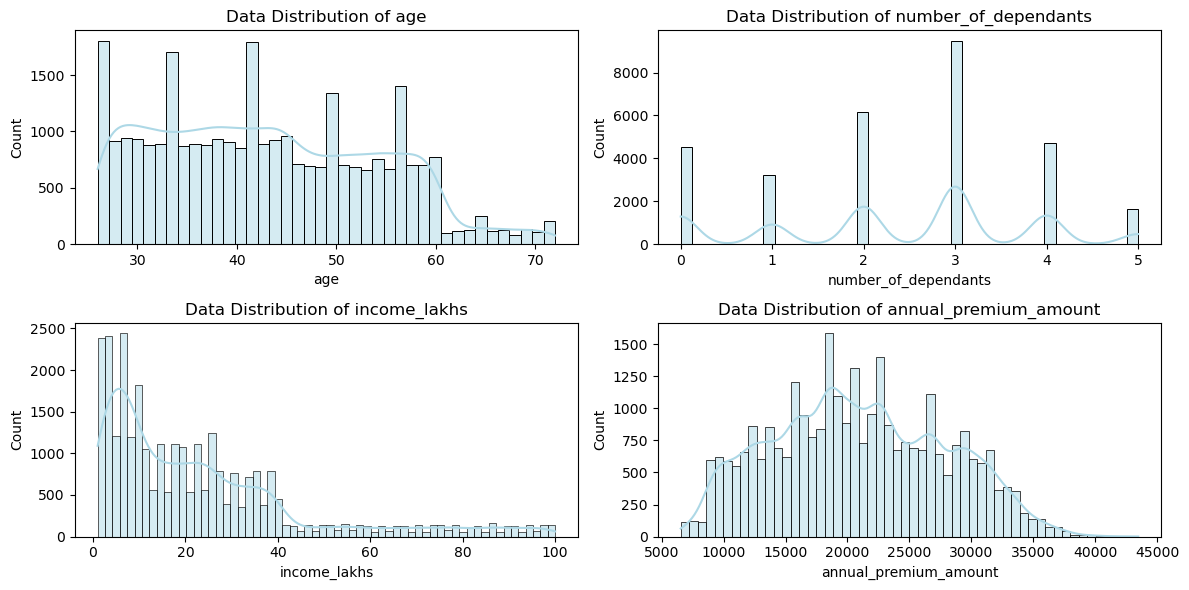

In [37]:
plt.figure(figsize=(12,6))

for i, col in enumerate(numerical_columns):
    plt.subplot(2, 2, i + 1)
    sns.histplot(x=df_2[col], color='lightblue', kde=True)
    plt.title(f"Data Distribution of {col}")

plt.tight_layout()
plt.show()

Finding all the Categorical columns 

In [38]:
categorical_cols = df.select_dtypes(exclude='number').columns

print(categorical_cols)

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')


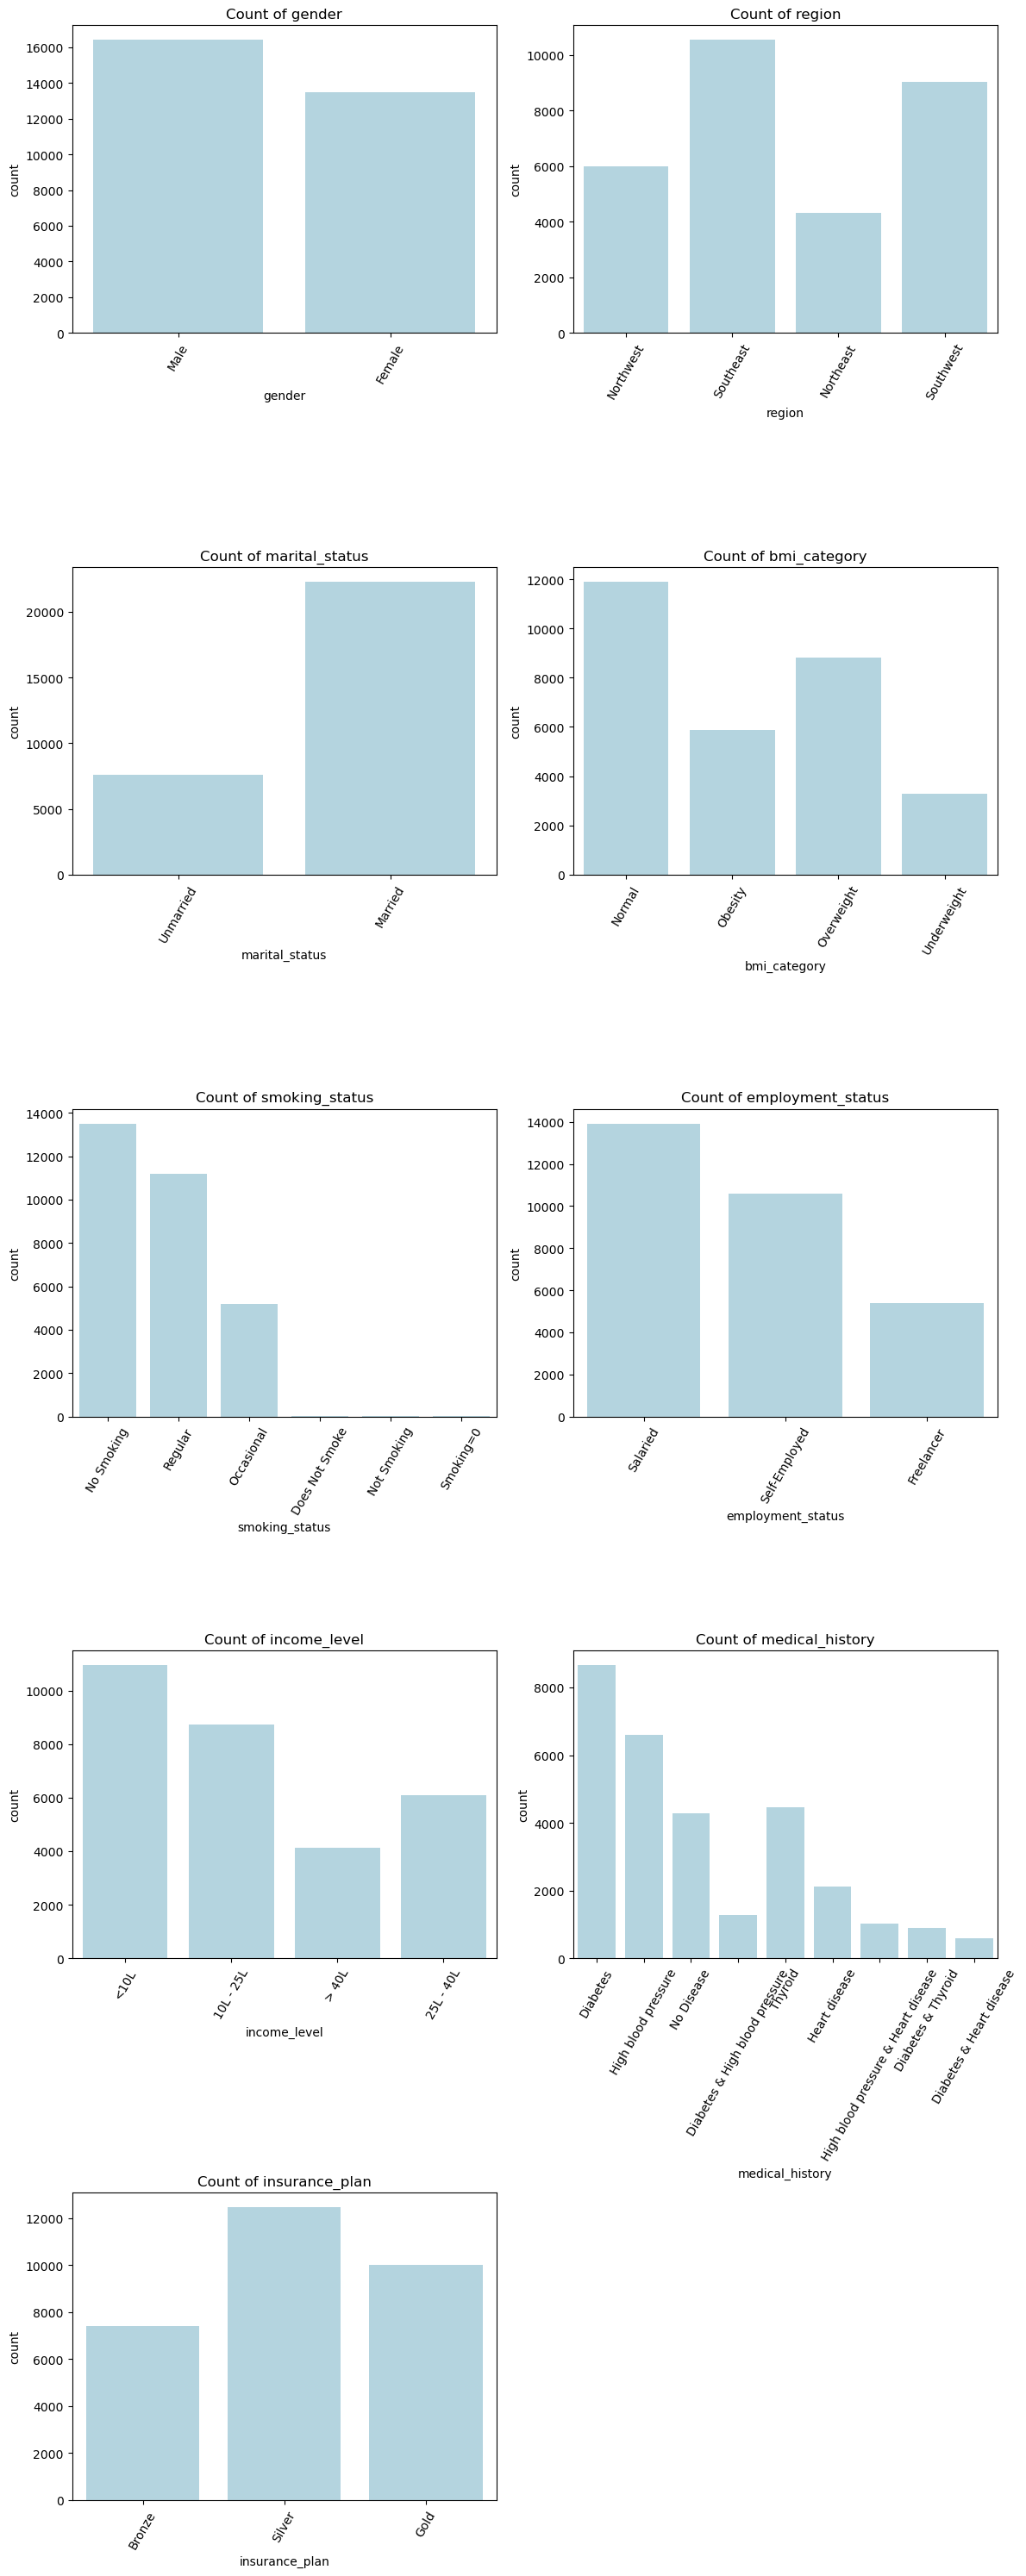

In [39]:
rows = (len(categorical_cols) + 1) // 2

plt.figure(figsize=(12, rows*6))

for i, col in enumerate(categorical_cols):
    plt.subplot(rows, 2, i + 1)
    sns.countplot(x=df[col], color='lightblue')
    plt.title(f"Count of {col}")
    plt.xticks(rotation=60)
    plt.tight_layout()

plt.show()

In [40]:
for col in categorical_cols:
    print(f"{col} -  {df_2[col].unique()}\n")

gender -  ['Male' 'Female']

region -  ['Northwest' 'Southeast' 'Northeast' 'Southwest']

marital_status -  ['Unmarried' 'Married']

bmi_category -  ['Normal' 'Obesity' 'Overweight' 'Underweight']

smoking_status -  ['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']

employment_status -  ['Salaried' 'Self-Employed' 'Freelancer']

income_level -  ['<10L' '10L - 25L' '> 40L' '25L - 40L']

medical_history -  ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']

insurance_plan -  ['Bronze' 'Silver' 'Gold']



Inside Smoking column there are values ( Smoking=0,Doesn not smoke and not smoking) Which all means Not smoking

In [41]:
df_2["smoking_status"] = df_2["smoking_status"].replace({

    "Smoking=0" : "No Smoking", 
    "Does Not Smoke" : "No Smoking", 
    "Not Smoking" : "No Smoking"
    })

df_2["smoking_status"].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

### Bivariate Analysis

In [42]:
numerical_features = ["age","income_lakhs","number_of_dependants"]

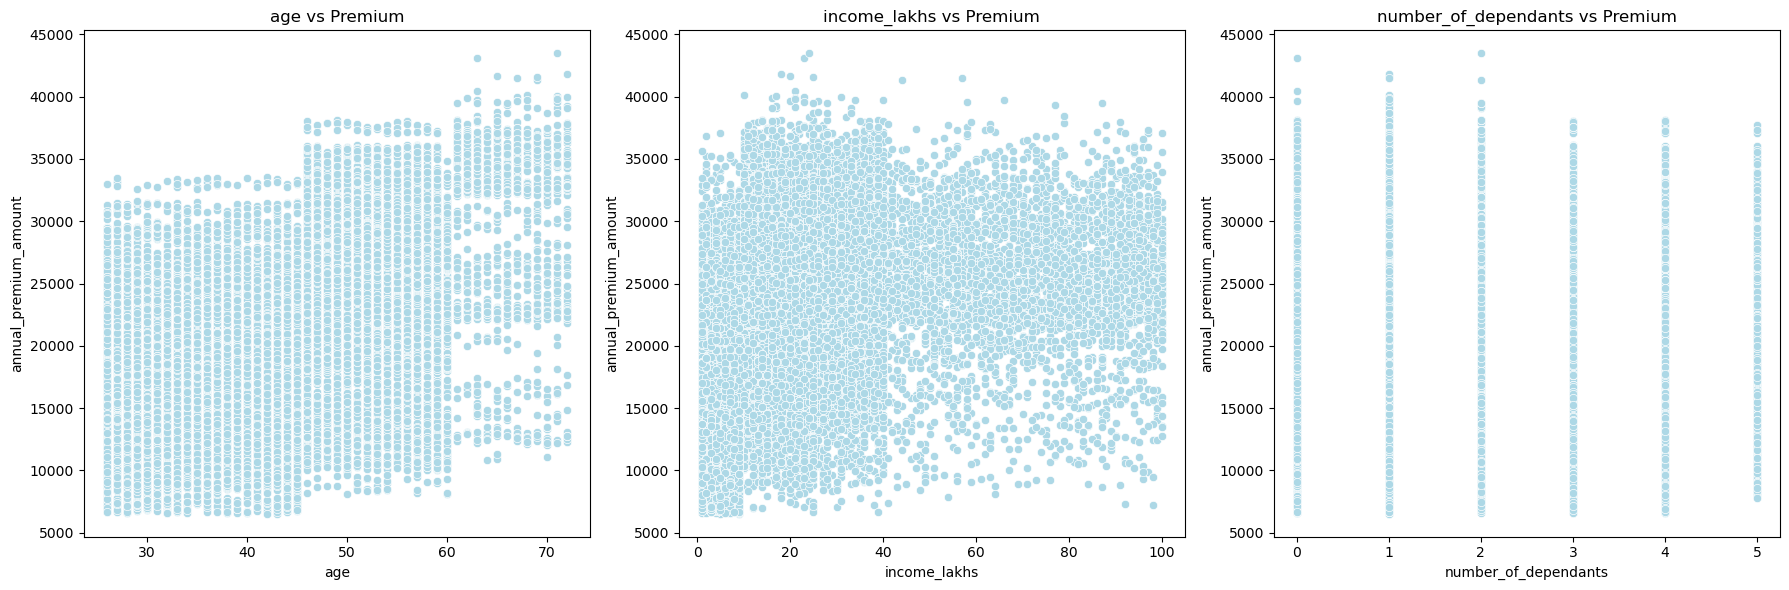

In [43]:
plt.figure(figsize=(18, 6)) 

for i, col in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(data=df_2, x=col, y="annual_premium_amount", color='lightblue')
    plt.title(f"{col} vs Premium")

plt.tight_layout()
plt.show()

### Barplot ( Percentage Share of Premium vs Catergorical Data )

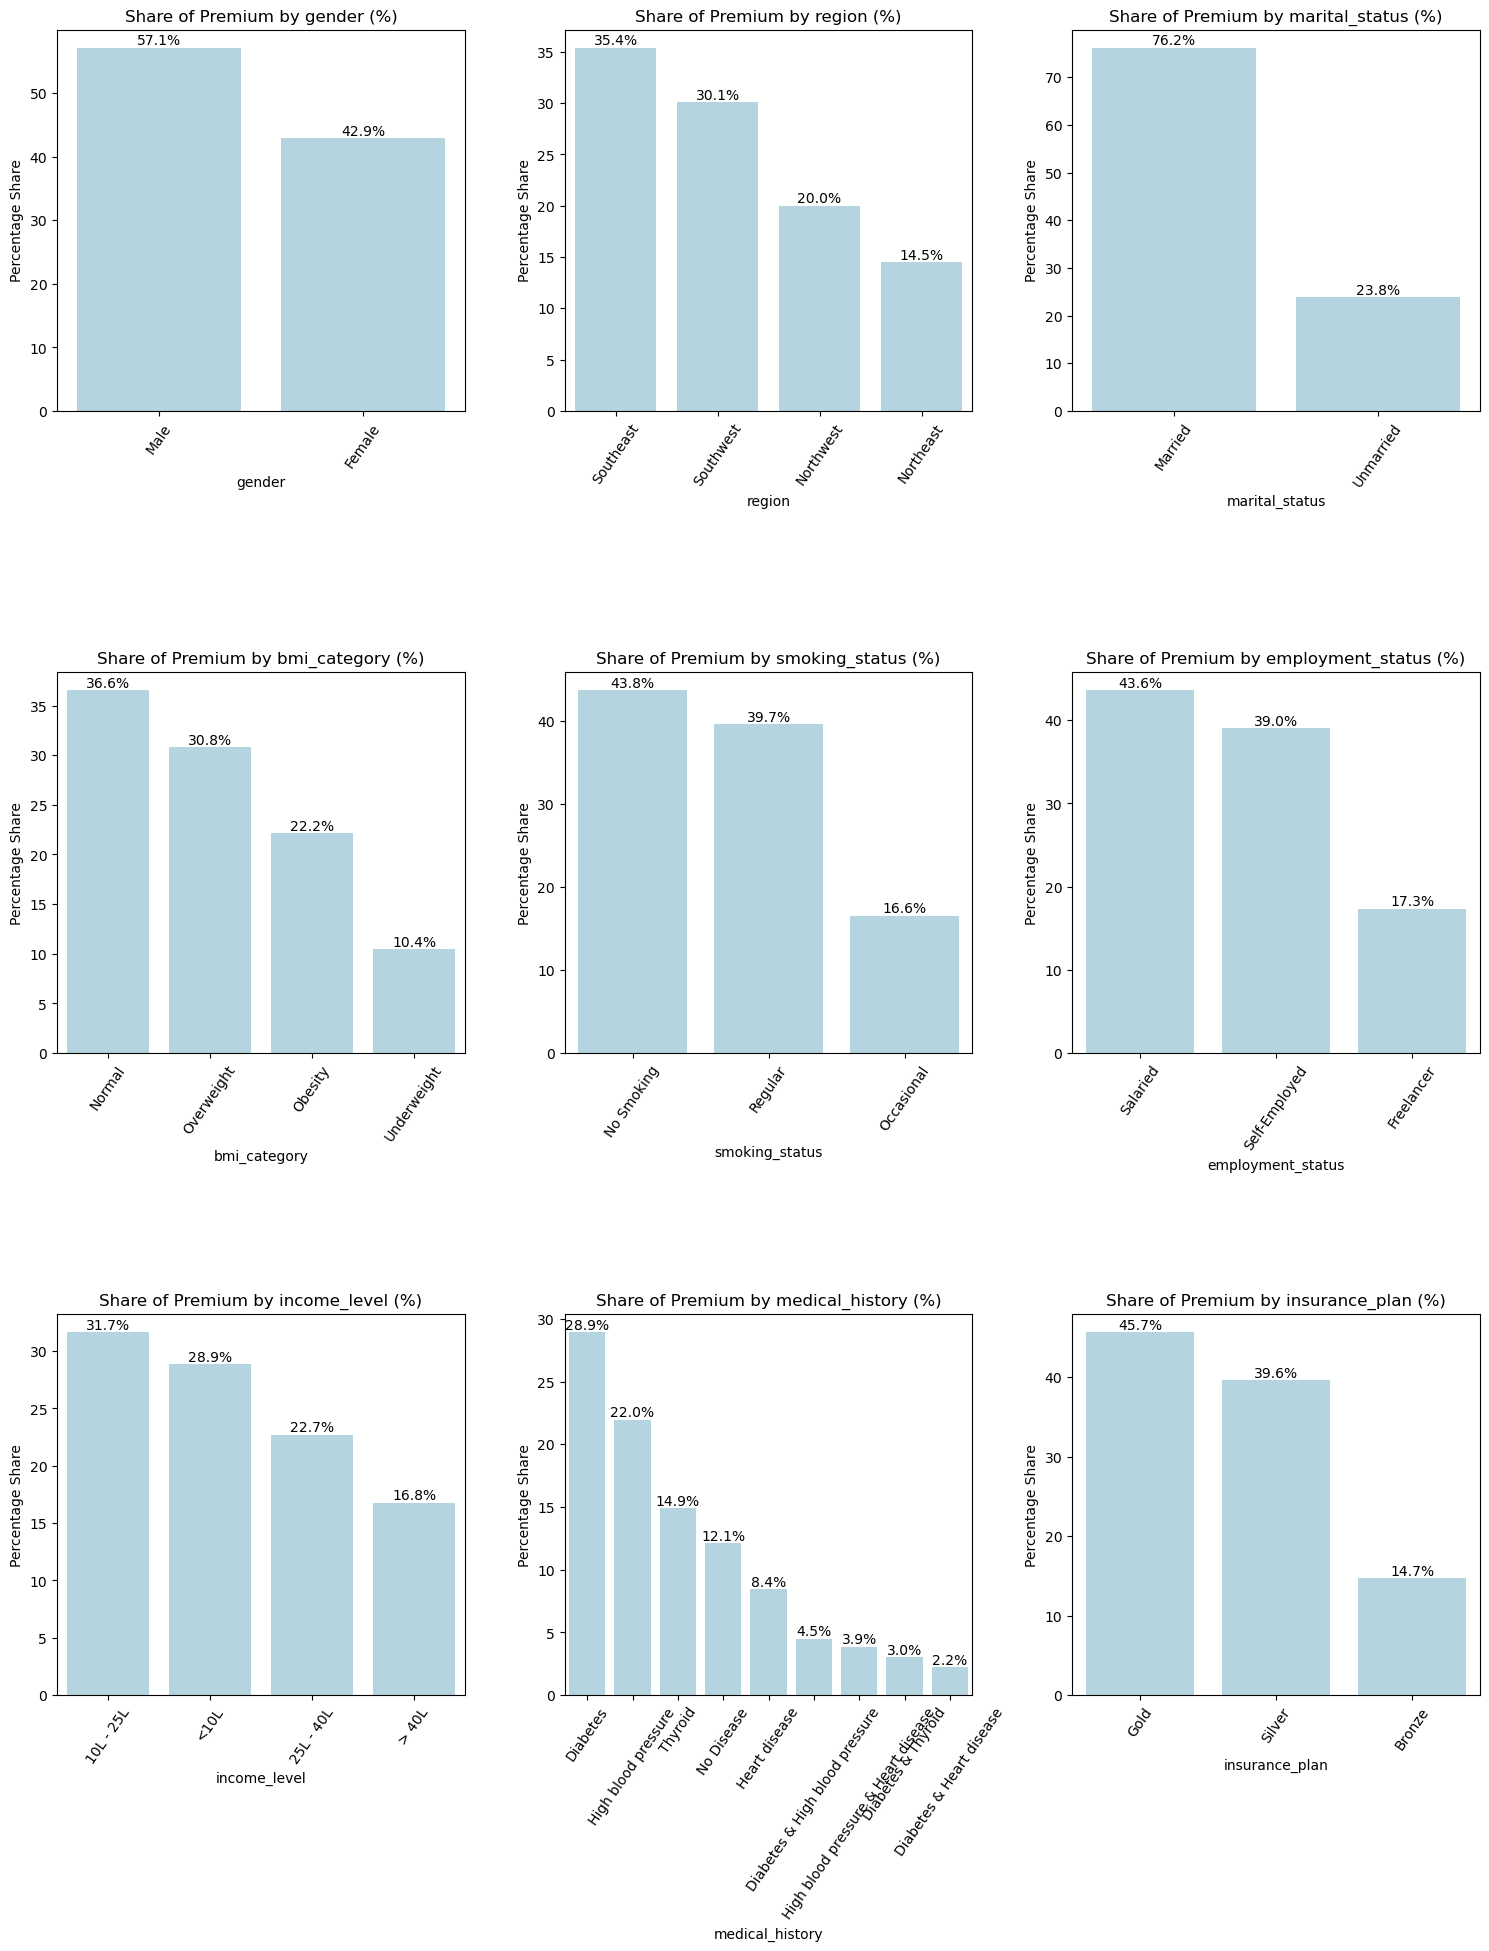

In [44]:
rows = (len(categorical_cols) + 1) // 2 
plt.figure(figsize=(15, rows * 6))

for i, col in enumerate(categorical_cols):
    plt.subplot(rows, 3, i + 1)
    
    group_sum = df_2.groupby(col)["annual_premium_amount"].sum()
    percent_data = (group_sum / group_sum.sum()) * 100
    
    percent_data = percent_data.sort_values(ascending=False)
    
    ax = sns.barplot(x=percent_data.index, y=percent_data.values, color='lightblue')

    plt.title(f"Share of Premium by {col} (%)")
    plt.ylabel("Percentage Share")
    plt.xticks(rotation=55)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Average Premium vs Categories

Most important as it will help me at the time of Feature Engineering to assign the Odinal values in label encoding 

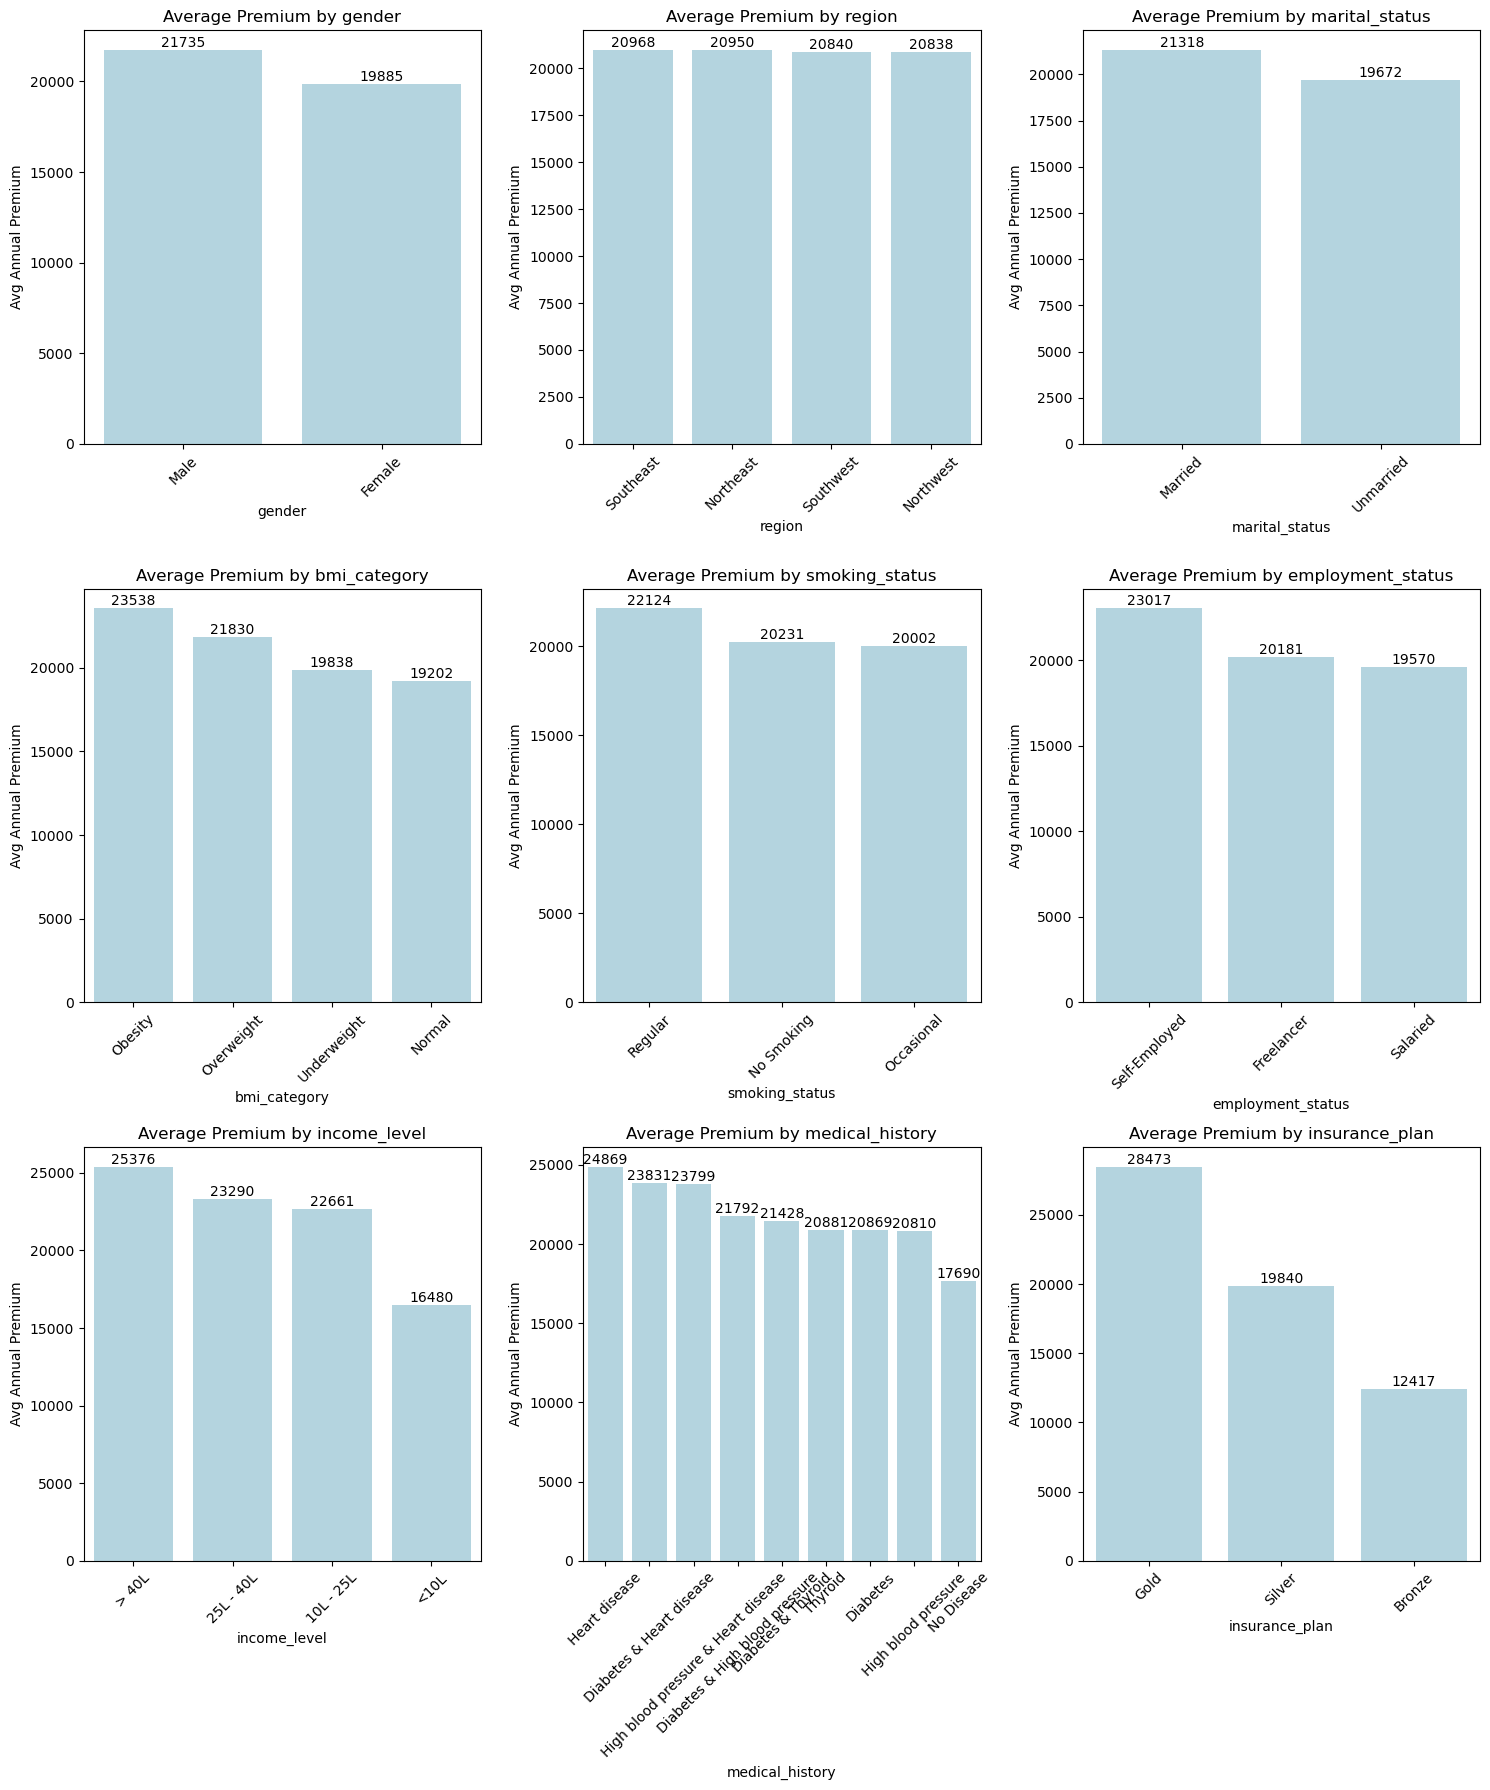

In [45]:
rows = (len(categorical_cols) + 2) // 3 

plt.figure(figsize=(15, rows * 6))

for i, col in enumerate(categorical_cols):
    plt.subplot(rows, 3, i + 1)
    avg_data = df_2.groupby(col)["annual_premium_amount"].mean()
    avg_data = avg_data.sort_values(ascending=False)
    
    ax = sns.barplot(x=avg_data.index, y=avg_data.values, color='lightblue')

    plt.title(f"Average Premium by {col}")
    plt.ylabel("Avg Annual Premium")
    plt.xticks(rotation=45)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()


### Employment Status vs Plan Preference

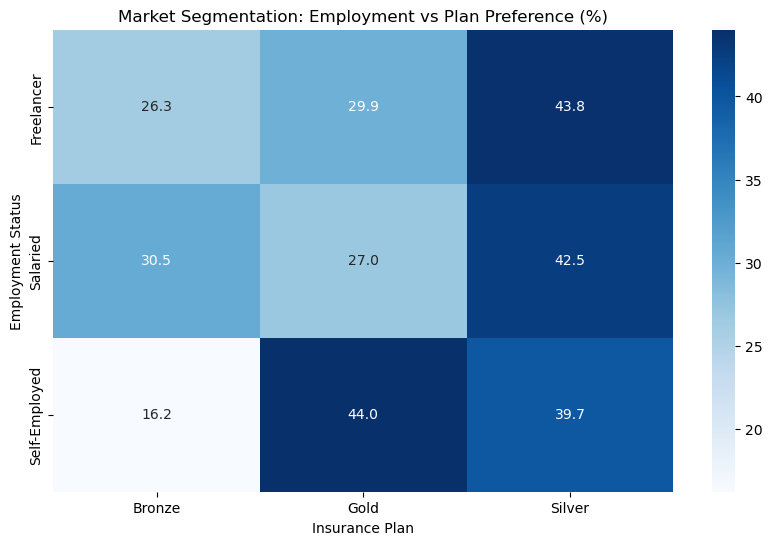

In [46]:
cross_tab_prop = pd.crosstab(df_2['employment_status'], df_2['insurance_plan'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab_prop, annot=True, fmt='.1f', cmap='Blues')
plt.title("Market Segmentation: Employment vs Plan Preference (%)")
plt.ylabel("Employment Status")
plt.xlabel("Insurance Plan")
plt.show()


### Average Premium: Gender vs Smoker Status

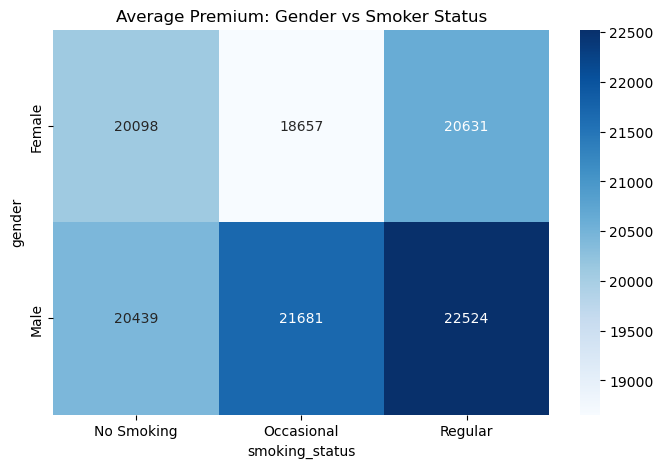

In [47]:
premium_matrix = pd.crosstab(
    index=df_2['gender'], 
    columns=df_2['smoking_status'], 
    values=df_2['annual_premium_amount'], 
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))
sns.heatmap(premium_matrix, annot=True, fmt='.0f', cmap='Blues')
plt.title("Average Premium: Gender vs Smoker Status")
plt.show()


### Average Annual Premium: Smoking vs Medical History

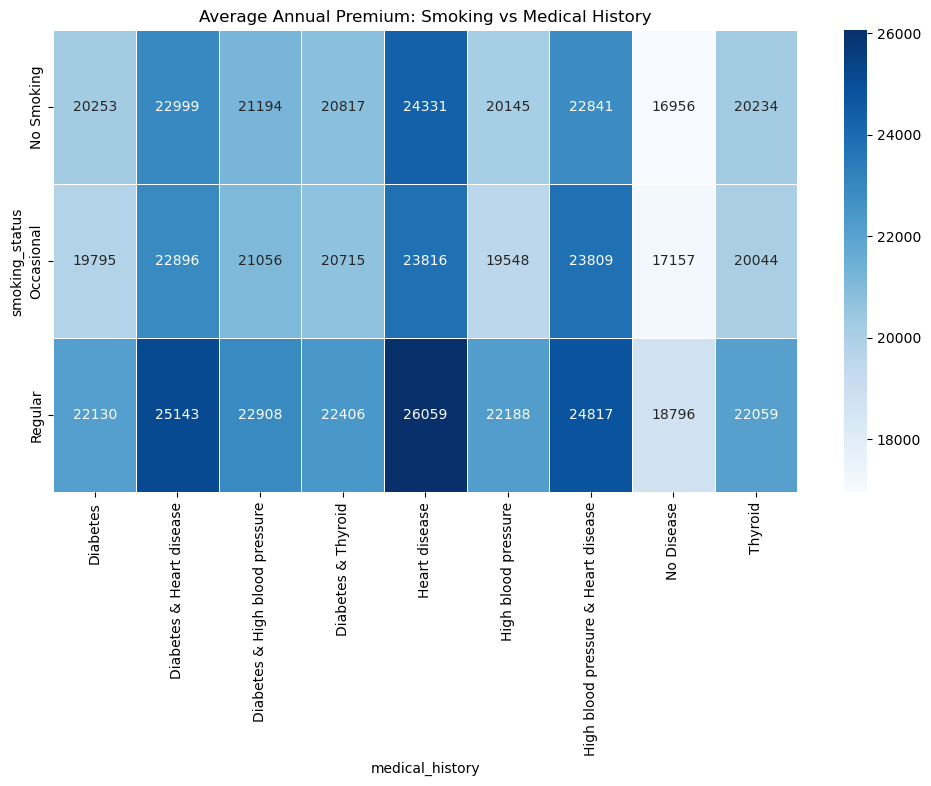

In [48]:
risk_matrix = pd.crosstab(
    index=df_2['smoking_status'], 
    columns=df_2['medical_history'], 
    values=df_2['annual_premium_amount'], 
    aggfunc='mean'  # Calculate the Average (Mean)
)
plt.figure(figsize=(12, 6))
sns.heatmap(risk_matrix, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5)

plt.title("Average Annual Premium: Smoking vs Medical History")
plt.show()


### Income vs Insurance Plan

In [49]:
crosstab = pd.crosstab(df_2["income_level"],df_2["insurance_plan"])
print(crosstab)

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L          799  3554    4354
25L - 40L          301  2631    3142
<10L              6054   527    4341
> 40L              214  3287     618


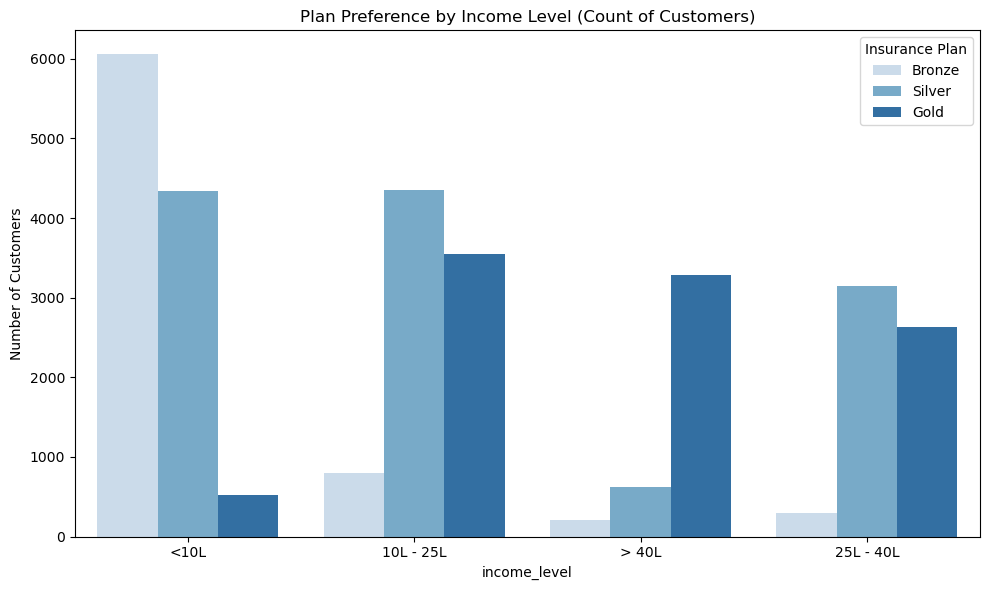

In [50]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_2, 
    x="income_level", 
    hue="insurance_plan", 
    palette="Blues"
)

plt.title("Plan Preference by Income Level (Count of Customers)")
plt.ylabel("Number of Customers")
plt.legend(title="Insurance Plan")

plt.tight_layout()
plt.show()


### Average Premium by Income and Insurance Plan

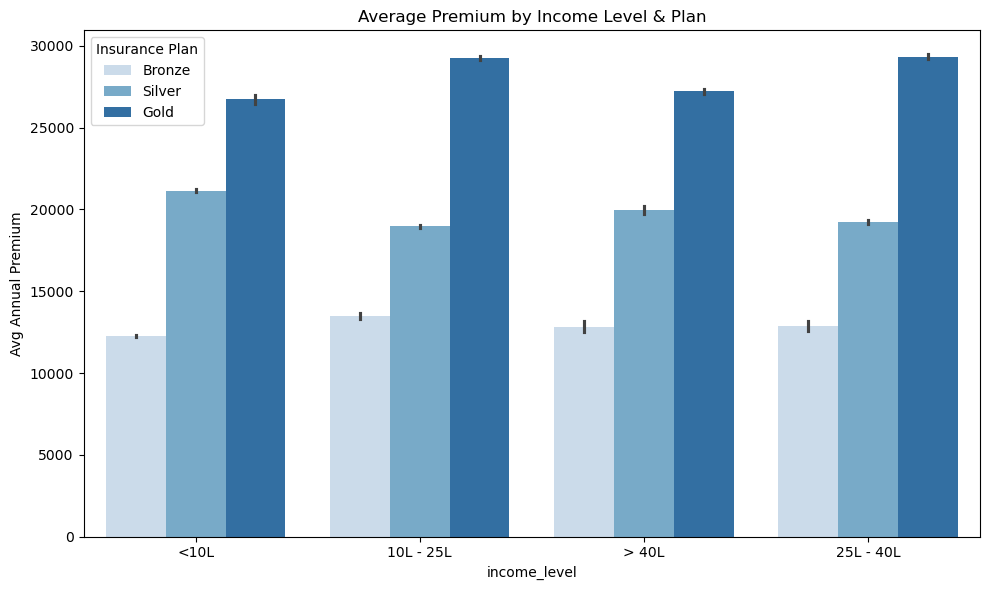

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_2, 
    x="income_level", 
    y="annual_premium_amount", 
    hue="insurance_plan", 
    palette="Blues"
)

plt.title("Average Premium by Income Level & Plan")
plt.ylabel("Avg Annual Premium")
plt.legend(title="Insurance Plan")

plt.tight_layout()
plt.show()


### Age vs Average Premium

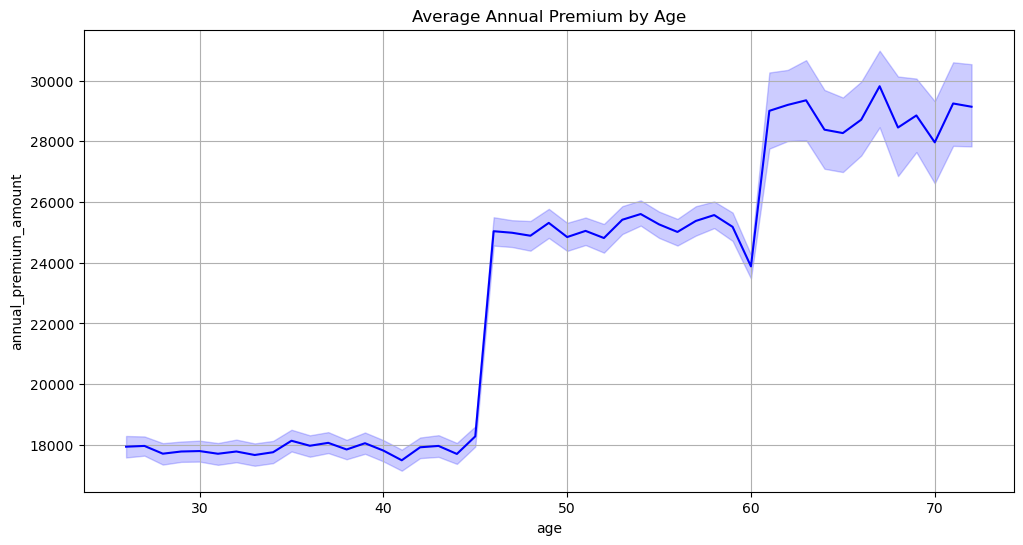

In [52]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=df_2, x="age", y="annual_premium_amount", color='blue')

plt.title("Average Annual Premium by Age")
plt.grid()
plt.show()

### Employment Status Vs Avg Premium 

employment_status
Salaried         19569.725200
Freelancer       20181.463779
Self-Employed    23016.534217
Name: annual_premium_amount, dtype: float64


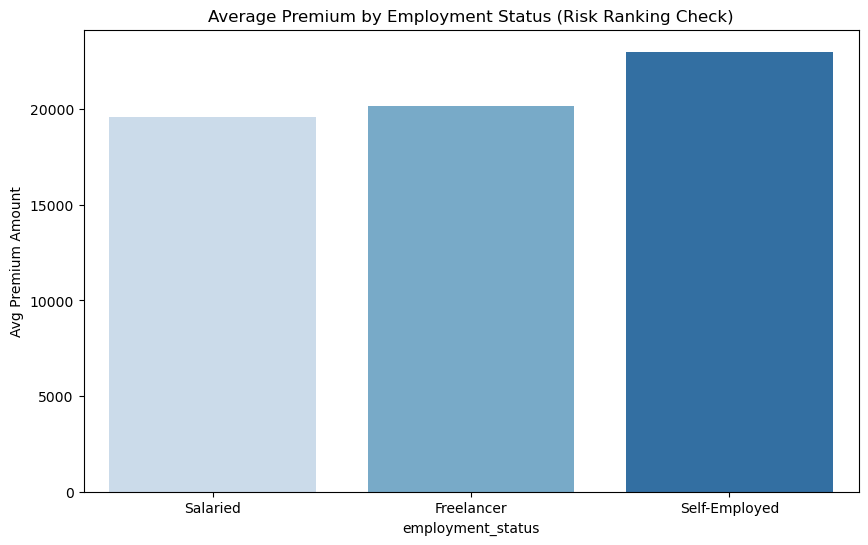

In [53]:
job_price = df_2.groupby('employment_status')['annual_premium_amount'].mean().sort_values()

print(job_price)

plt.figure(figsize=(10, 6))
sns.barplot(x=job_price.index, y=job_price.values,hue=job_price.index,palette="Blues")

plt.title("Average Premium by Employment Status (Risk Ranking Check)")
plt.ylabel("Avg Premium Amount")
plt.show()

### Saving the Clean Dataset

In [54]:
df_2.to_csv("premium_senior_clean.csv", index=False)

# Feature Engineering

In [55]:
df_cleaned = pd.read_csv("premium_senior_clean.csv")

df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


In [56]:
df_cleaned.shape

(29822, 13)

In [57]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29822 entries, 0 to 29821
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    29822 non-null  int64 
 1   gender                 29822 non-null  object
 2   region                 29822 non-null  object
 3   marital_status         29822 non-null  object
 4   number_of_dependants   29822 non-null  int64 
 5   bmi_category           29822 non-null  object
 6   smoking_status         29822 non-null  object
 7   employment_status      29822 non-null  object
 8   income_level           29822 non-null  object
 9   income_lakhs           29822 non-null  int64 
 10  medical_history        29822 non-null  object
 11  insurance_plan         29822 non-null  object
 12  annual_premium_amount  29822 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 3.0+ MB


In [58]:
df_cleaned["income_level"].value_counts()

income_level
<10L         10922
10L - 25L     8707
25L - 40L     6074
> 40L         4119
Name: count, dtype: int64

Since we already have the exact income salary so actually we dont need income_level . it will increase the multicollinearinty and also increace the dimentionality which is not a good thing

In [59]:
df_cleaned = df_cleaned.drop(columns="income_level")

Since our income was found to be Rightly Skewed hence lets normalize it 

In [60]:
df_cleaned["income_log"] = np.log1p(df_cleaned["income_lakhs"])

df_cleaned["income_log"].describe()

count    29822.000000
mean         2.756863
std          0.981913
min          0.693147
25%          2.079442
50%          2.890372
75%          3.496508
max          4.615121
Name: income_log, dtype: float64

Per Capita Income of the family ( 1 + dependants )

In [61]:
df_cleaned["per_capita_income"] = df_cleaned["income_lakhs"]/(df_cleaned["number_of_dependants"] + 1)

Dividing the AGE into 3 major brackets using commulative step coding ( as in the Age vs Premium chart we can clearly see that the company have some age bracket criteria)

In [62]:
df_cleaned["is_over_45"] = (df_cleaned["age"]>45).astype(int)
df_cleaned["is_over_60"] = (df_cleaned["age"]>60).astype(int)

### OneHot Encoding for Nominal categories

In [63]:
df_cleaned = pd.get_dummies(df_cleaned,columns=["gender", "region"],drop_first=True,dtype=int)

### TRAIN TEST SPLIT 

In [64]:
from sklearn.model_selection import train_test_split

X = df_cleaned.drop(columns=["annual_premium_amount"])
y = df_cleaned["annual_premium_amount"]

Train Test Split ( we are splitting the data into Training and testing sets)

In [65]:
X_train , X_test , y_train , y_test =train_test_split(X,y,test_size=0.2,random_state=42)

Making Training_data column to now calculate all the Target Mean Encoding without leaking the data

In [66]:
training_data = X_train.copy()
training_data["annual_premium_amount"] = y_train

Now that we have splitted the X and y we can do the Target Means Encoding and Odinal Encoding Seperately to prevent data Leakag

### Odinal Encoding ( Based on order of priority )

Doing the One Hot encoding based ont the priority found in my EDA 

In [67]:
X_train['insurance_plan'] = X_train['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})
X_test['insurance_plan'] = X_test['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})


X_train['employment_status'] = X_train['employment_status'].map({'Freelancer': 1, 'Salaried': 2, 'Self-Employed': 3})
X_test['employment_status'] = X_test['employment_status'].map({'Freelancer': 1, 'Salaried': 2, 'Self-Employed': 3})

### Target Mean Encoding

Based on observation in EDA. Few columnbs have non linear Odinal relation with Annual Preiumn 

That is why im using groupby average premium for those target Columns

In [68]:
target_cols = ['medical_history', 'bmi_category', 'marital_status', 'smoking_status']
global_mean_premium = y_train.mean()

for col in target_cols:
    mean_dict = training_data.groupby(col)['annual_premium_amount'].mean().to_dict()
    
    X_train[col] = X_train[col].map(mean_dict)
    
    X_test[col] = X_test[col].map(mean_dict)
    X_test[col] = X_test[col].fillna(global_mean_premium)

### FEATURE CREATION 

Based on EDA and the Domain knowledge i have created few new features ( if they will be helpful then i will keep it else i will drop it )

In [69]:
def feature_creation(data):
    data["risk_smoke"] = data['age'] * data['smoking_status']
    
    raw_health = data["bmi_category"] * data['medical_history'] * data["smoking_status"]
    data["health_risk_score"] = np.log1p(raw_health)
    
    raw_weighted = data["age"] * data["health_risk_score"]
    data["weighted_risk_score"] = np.log1p(raw_weighted)
    
    return data

X_train = feature_creation(X_train)
X_test = feature_creation(X_test)

In [70]:
X_train.head()

,age,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_lakhs,medical_history,insurance_plan,income_log,per_capita_income,is_over_45,is_over_60,gender_Male,region_Northwest,region_Southeast,region_Southwest,risk_smoke,health_risk_score,weighted_risk_score
7665,49,21323.933869,4,21854.529212,20241.931481,1,2,24866.865020,2,1.098612,0.400000,1,0,1,0,1,0,9.918546e+05,30.028966,7.294662
6379,55,21323.933869,4,19214.565685,22143.061846,3,12,20922.258611,3,2.564949,2.400000,1,0,1,0,0,1,1.217868e+06,29.817272,7.403031
15057,44,19730.765229,1,19877.130202,20241.931481,2,22,23935.956962,2,3.135494,11.000000,0,0,0,0,1,0,8.906450e+05,29.895974,7.182673
10351,72,21323.933869,2,21854.529212,20241.931481,3,26,20782.916492,3,3.295837,8.666667,1,1,1,0,0,1,1.457419e+06,29.849562,7.673301
25171,64,21323.933869,1,19877.130202,20241.931481,2,11,24866.865020,3,2.484907,5.500000,1,1,1,1,0,0,1.295484e+06,29.934128,7.558404


In [71]:
X_test.shape

(5965, 20)

In [72]:
X_train.shape

(23857, 20)

### Scaling and Baseline model

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error , r2_score

Selecting Columns that need Scaling ( excluding the OHE Encoded colums )

In [74]:
scaling_cols = [
    'age', 'number_of_dependants', 'income_lakhs', 'per_capita_income', 
    'medical_history', 'bmi_category', 'marital_status', 'smoking_status',
    'risk_smoke', 'health_risk_score', 'weighted_risk_score'
]

scaler = StandardScaler()

X_train[scaling_cols] = scaler.fit_transform(X_train[scaling_cols])
X_test[scaling_cols] = scaler.transform(X_test[scaling_cols])

### Baseline Model ( Random FOrest )

In [75]:
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
training_score = rf_base.score(X_train,y_train)
testing_score = rf_base.score(X_test,y_test)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R2: {r2:,.2f}")
print(f"Training Score for the baseline model is : {training_score:,.2f}")
print(f"Testing Score for the baseline model is : {testing_score:,.2f}")


Mean Absolute Error (MAE): 267.05
Root Mean Squared Error (RMSE): 322.21
R2: 1.00
Training Score for the baseline model is : 1.00
Testing Score for the baseline model is : 1.00


### Feature Importance of Baseline model - Randomforest 


In [76]:
importance = rf_base.feature_importances_
feature_names= X_train.columns

impt_feature_df = pd.DataFrame({"features":feature_names , "importance" : importance}).sort_values(by="importance",ascending=False)

impt_feature_df

,features,importance
8,insurance_plan,0.778986
18,health_risk_score,0.130677
19,weighted_risk_score,0.075460
4,smoking_status,0.004952
17,risk_smoke,0.003092
0,age,0.002214
12,is_over_60,0.001493
7,medical_history,0.001079
11,is_over_45,0.000589
10,per_capita_income,0.000353


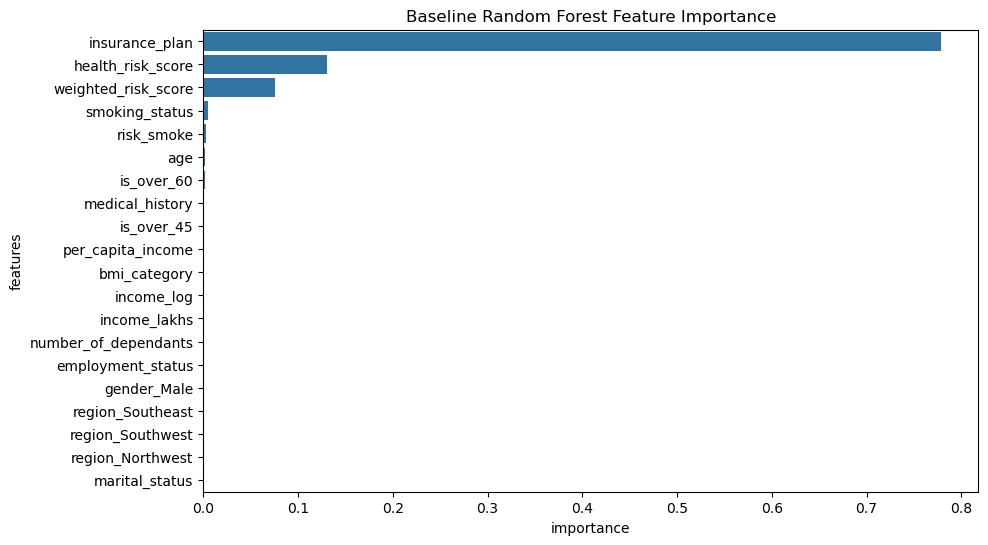

In [77]:
plt.figure(figsize=(10, 6))
sns.barplot(data=impt_feature_df,x='importance', y='features')
plt.title('Baseline Random Forest Feature Importance')
plt.show()

### Checking Coreelation Matrix

In [78]:
X_train.columns

Index(['age', 'marital_status', 'number_of_dependants', 'bmi_category',
       'smoking_status', 'employment_status', 'income_lakhs',
       'medical_history', 'insurance_plan', 'income_log', 'per_capita_income',
       'is_over_45', 'is_over_60', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'risk_smoke',
       'health_risk_score', 'weighted_risk_score'],
      dtype='object')

In [79]:
cm_matrix_df = X_train.copy()

cm_matrix_df["annual_premium_price"] = y_train

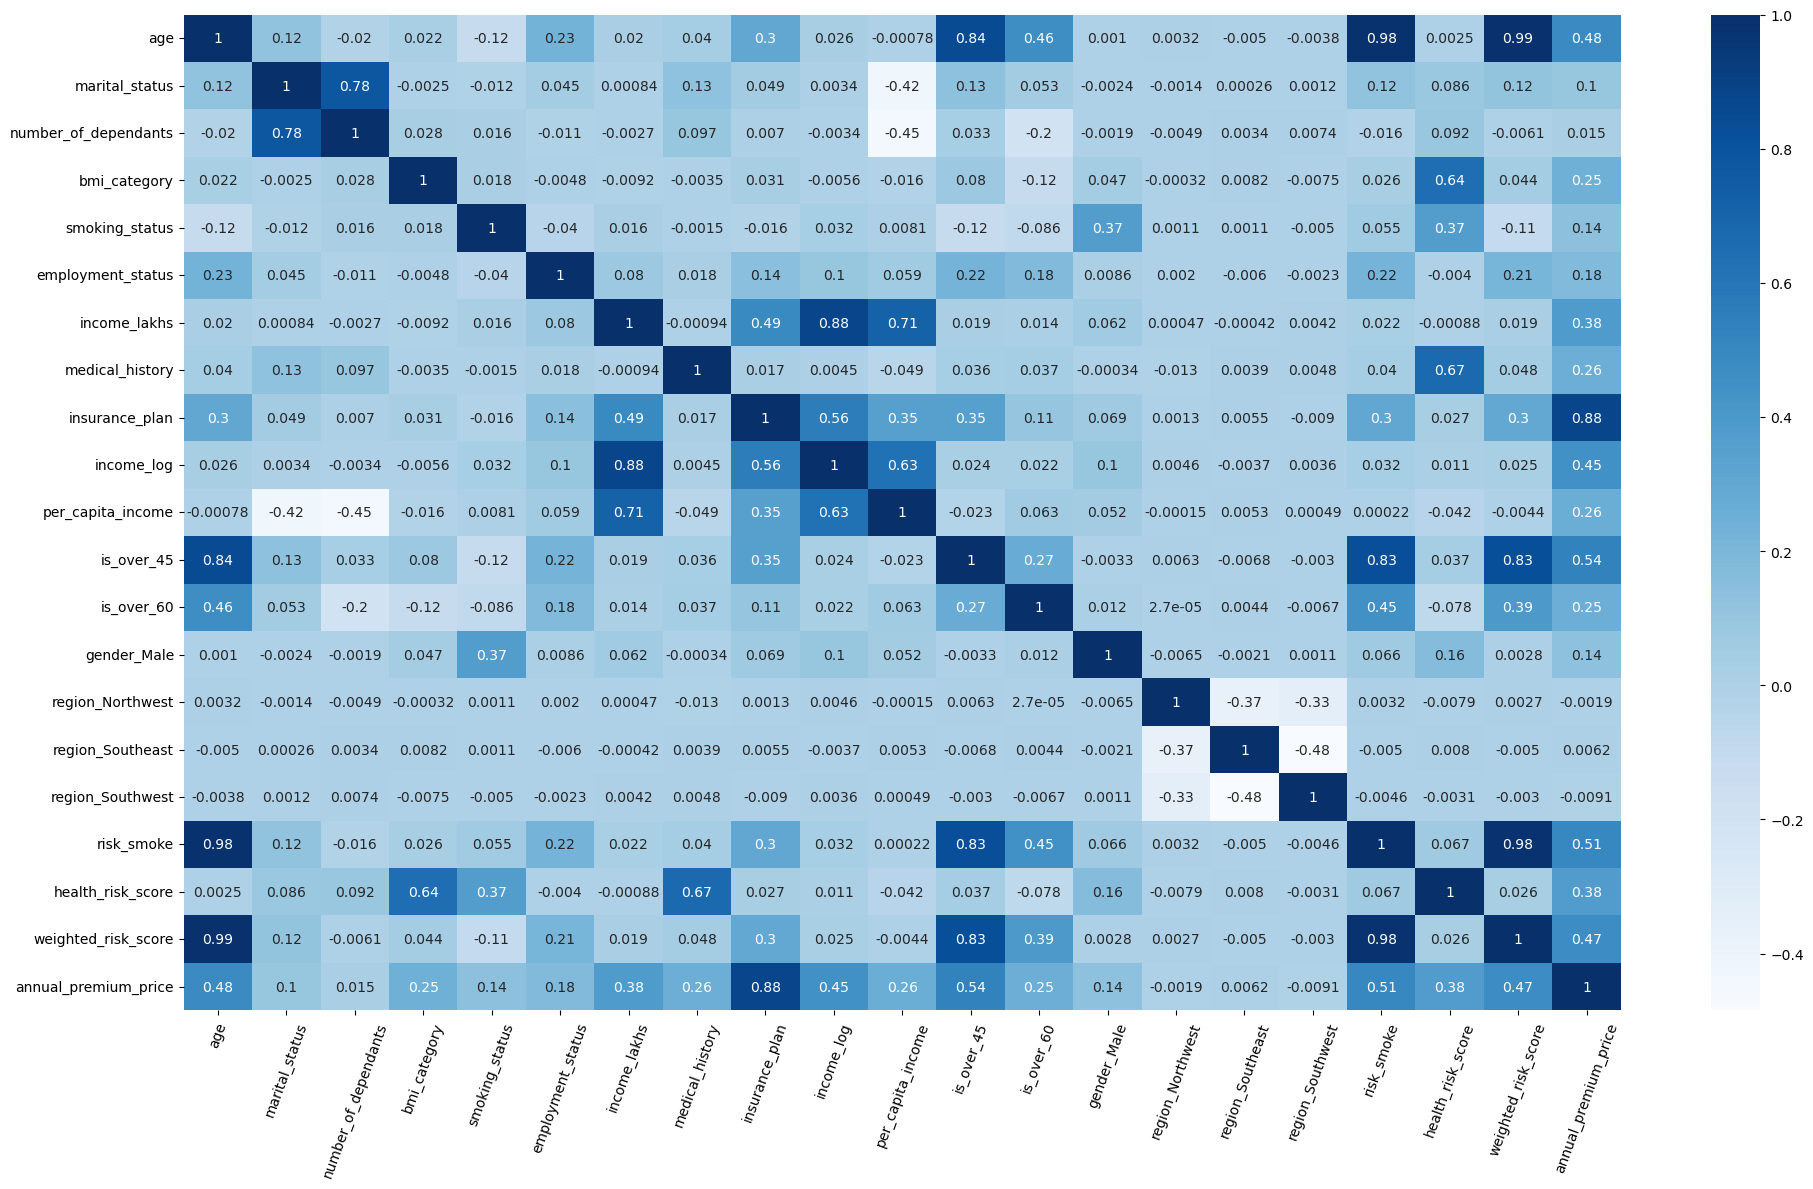

In [80]:
cm = cm_matrix_df.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm,annot=True,cmap="Blues")
plt.xticks(rotation=70)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### VIF Score For Checking Multi-collinearity 

In [81]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [82]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["features"] = data.columns
    vif_df["vif_score"] = [variance_inflation_factor(data.values,i) for i in range (data.shape[1])]
    return vif_df.sort_values(by="vif_score",ascending=False)

calculate_vif(X_train)

,features,vif_score
0,age,640.364090
17,risk_smoke,541.190918
18,health_risk_score,405.418640
7,medical_history,185.114597
3,bmi_category,167.228938
19,weighted_risk_score,106.218925
4,smoking_status,68.509648
9,income_log,24.700370
8,insurance_plan,14.785090
5,employment_status,9.730984


Now based on the FEATURE IMPORTANCE , Correlation and VIF ( multi- collianarity ). We will Drop the Features that are not soo useful and cause the multicollinearity 

### Feature Selection ( Pruining )

In [83]:
columns_to_drop = ["income_lakhs","medical_history","bmi_category"]

X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

In [84]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["features"] = data.columns
    vif_df["vif_score"] = [variance_inflation_factor(data.values,i) for i in range (data.shape[1])]
    return vif_df.sort_values(by="vif_score",ascending=False)

calculate_vif(X_train)

,features,vif_score
0,age,638.305382
14,risk_smoke,540.882883
16,weighted_risk_score,105.092518
6,income_log,17.865974
3,smoking_status,17.648040
5,insurance_plan,14.495127
4,employment_status,8.840136
8,is_over_45,7.410822
2,number_of_dependants,3.149520
12,region_Southeast,2.941837


### Re-Training the Baseline model - Random Forest to check the new list of important features

In [85]:
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
training_score = rf_base.score(X_train,y_train)
testing_score = rf_base.score(X_test,y_test)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R2: {r2:,.2f}")
print(f"Training Score for the baseline model is : {training_score:,.2f}")
print(f"Testing Score for the baseline model is : {testing_score:,.2f}")


Mean Absolute Error (MAE): 268.07
Root Mean Squared Error (RMSE): 323.57
R2: 1.00
Training Score for the baseline model is : 1.00
Testing Score for the baseline model is : 1.00


### Retrained baseline model - Feature Importance List 

In [86]:
importance = rf_base.feature_importances_
feature_names= X_train.columns

impt_feature_df = pd.DataFrame({"features":feature_names , "importance" : importance}).sort_values(by="importance",ascending=False)

impt_feature_df

,features,importance
5,insurance_plan,0.778986
15,health_risk_score,0.131875
16,weighted_risk_score,0.075261
3,smoking_status,0.005065
14,risk_smoke,0.003098
0,age,0.002364
9,is_over_60,0.001563
8,is_over_45,0.000590
7,per_capita_income,0.000377
6,income_log,0.000320


Since the feature ( risk_smoke ) have a high VIF and importance very low so i will drop it in this interation 

In [87]:
X_train = X_train.drop(columns=["risk_smoke"])
X_test = X_test.drop(columns=["risk_smoke"])

### Re Training the baseline model for checking feature importance now 

In [88]:
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
training_score = rf_base.score(X_train,y_train)
testing_score = rf_base.score(X_test,y_test)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R2: {r2:,.2f}")
print(f"Training Score for the baseline model is : {training_score:,.2f}")
print(f"Testing Score for the baseline model is : {testing_score:,.2f}")


Mean Absolute Error (MAE): 268.10
Root Mean Squared Error (RMSE): 323.55
R2: 1.00
Training Score for the baseline model is : 1.00
Testing Score for the baseline model is : 1.00


In [89]:
importance = rf_base.feature_importances_
feature_names= X_train.columns

impt_feature_df = pd.DataFrame({"features":feature_names , "importance" : importance}).sort_values(by="importance",ascending=False)

impt_feature_df

,features,importance
5,insurance_plan,0.778986
14,health_risk_score,0.132166
15,weighted_risk_score,0.076465
3,smoking_status,0.005169
0,age,0.003191
9,is_over_60,0.002192
8,is_over_45,0.000622
7,per_capita_income,0.000381
6,income_log,0.000321
2,number_of_dependants,0.000126


### Re Calculating the VIF score 

In [90]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["features"] = data.columns
    vif_df["vif_score"] = [variance_inflation_factor(data.values,i) for i in range (data.shape[1])]
    return vif_df.sort_values(by="vif_score",ascending=False)

calculate_vif(X_train)

,features,vif_score
0,age,130.186647
15,weighted_risk_score,104.359183
6,income_log,17.865635
5,insurance_plan,14.495126
4,employment_status,8.838614
8,is_over_45,7.410227
2,number_of_dependants,3.149383
12,region_Southeast,2.941772
1,marital_status,2.930057
13,region_Southwest,2.679228


In [91]:
X_train = X_train.drop(columns=["income_log","weighted_risk_score"])
X_test = X_test.drop(columns=["income_log","weighted_risk_score"])

### Re Calculating the VIF score 

In [92]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["features"] = data.columns
    vif_df["vif_score"] = [variance_inflation_factor(data.values,i) for i in range (data.shape[1])]
    return vif_df.sort_values(by="vif_score",ascending=False)

calculate_vif(X_train)

,features,vif_score
5,insurance_plan,8.795905
4,employment_status,7.802836
7,is_over_45,6.371802
0,age,4.051391
2,number_of_dependants,3.090538
1,marital_status,2.915760
11,region_Southeast,2.802222
12,region_Southwest,2.546815
9,gender_Male,2.488763
10,region_Northwest,2.032752


In [93]:
X_train.columns

Index(['age', 'marital_status', 'number_of_dependants', 'smoking_status',
       'employment_status', 'insurance_plan', 'per_capita_income',
       'is_over_45', 'is_over_60', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'health_risk_score'],
      dtype='object')

## Training the Main Base Models ( Using K - fold Cross Validation )

I am using top 3 Base models - XGBoost , RandomForest and LightGBM and then will use stacking to make a new Meta model which will be based on L2 Ridge Linear Regression to give Final Predictions

In [94]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_score
import time 

models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42,verbose=-1) 
    }

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name , model in models.items():
    print(f"Training and Cross Validating the Model - {name}")
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
    cv_mae = -cv_scores
    cv_results[name] = cv_mae
    
    print(f"Model - {name} Trained \nScore :- CV MAE: {cv_mae.mean():,.2f}")

Training and Cross Validating the Model - Random Forest
Model - Random Forest Trained 
Score :- CV MAE: 270.42
Training and Cross Validating the Model - XGBoost
Model - XGBoost Trained 
Score :- CV MAE: 262.65
Training and Cross Validating the Model - LightGBM
Model - LightGBM Trained 
Score :- CV MAE: 262.39


### This is our baseline scores for Our Main base models ( which we will use for trainign the Main Meta Stacking Model )

## Tuning XGBoost for best params

In [95]:
from sklearn.model_selection import RandomizedSearchCV

xgb_grid = {
    'n_estimators': [50, 100, 150, 200, 250, 300,400, 500],
    'learning_rate': [0.01, 0.05, 0.07, 0.1, 0.15,0.2],
    'max_depth': [2, 3, 5, 7, 9, 11],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}
print("Tuning XGBoost Models")
xgb_tuner = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_grid,
    n_iter=50,                                 
    cv=kf,                                     
    scoring='neg_mean_absolute_error',
    random_state=42,                                
)

xgb_tuner.fit(X_train, y_train)

best_xgb_model = xgb_tuner.best_estimator_
tuned_mae = -xgb_tuner.best_score_

print("Tuned XGBoost Performance")
print(f"Best Parameters Found:- {xgb_tuner.best_params_}\n")
print(f"Tuned CV MAE: ₹{tuned_mae:,.2f}")

Tuning XGBoost Models
Tuned XGBoost Performance
Best Parameters Found:- {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.07, 'colsample_bytree': 0.9}

Tuned CV MAE: ₹260.85


## Tuning LightGBM for best params

In [96]:
lgbm_grid = {
    'n_estimators': [50,100, 150, 200, 250, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.07, 0.1, 0.15, 0.2, 0.25],
    'max_depth': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],              
    'num_leaves': [30, 40, 50, 60, 70, 100],         
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}
print("Tuning LightGBM Models")
lgbm_tuner = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=42, verbose=-1),
    param_distributions=lgbm_grid,
    n_iter=50,                                 
    cv=kf,                                     
    scoring='neg_mean_absolute_error',
    random_state=42,
    verbose=1                                  
)
lgbm_tuner.fit(X_train, y_train)

best_lgbm_model = lgbm_tuner.best_estimator_
lgbm_tuned_mae = -lgbm_tuner.best_score_

print("Tuned LightGBM Performance")
print(f"Best Parameters Found:- {lgbm_tuner.best_params_}\n")
print(f"Tuned CV MAE: {lgbm_tuned_mae:,.2f}")

Tuning LightGBM Models
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Tuned LightGBM Performance
Best Parameters Found:- {'subsample': 1.0, 'num_leaves': 30, 'n_estimators': 300, 'max_depth': 13, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Tuned CV MAE: 260.27


## Tuning Random Forest for best params

In [97]:
rf_grid = {

    "n_estimators" : [50, 100, 150, 200, 250, 300, 350, 400, 500], 
    "max_depth" : [2,3,4,5,7,9,11,13,15,17,19,21], 
    "max_features": ['sqrt', 1.0, 0.5],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 5, 6],
    
}

print("Tuning the Random Forest MOdel ")

rf_tuner = RandomizedSearchCV(

    estimator=RandomForestRegressor(random_state=42), 
    param_distributions=rf_grid,
    n_iter=50,
    cv=kf,
    scoring="neg_mean_absolute_error", 
    random_state=42
)

rf_tuner.fit(X_train , y_train)

best_rf_model = rf_tuner.best_estimator_
rf_tuned_mae = -rf_tuner.best_score_

print("Tuned the Random Forest Model")
print(f" Best Parameters Found :- {rf_tuner.best_params_}\n")
print(f" Tuned CV MAE :- {rf_tuned_mae:,.2f}")

Tuning the Random Forest MOdel 
Tuned the Random Forest Model
 Best Parameters Found :- {'n_estimators': 350, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 11}

 Tuned CV MAE :- 261.41


## Making the META-MODEL ( Stacking and ensembling Main Base models ) 

For the Meta Model i have selected L2 Regularization Ridge Linear Model which take values from Main Base Models to Predict Final Value

In [98]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

main_base_models = [
    ('xgb', best_xgb_model),
    ('lgbm', best_lgbm_model),
    ('rf', best_rf_model)
]

stacked_model = StackingRegressor(
    estimators=main_base_models,
    final_estimator=Ridge(alpha=1.0),
    cv=kf,
)

print("Cross validating the Ensemble or Meta Model")
stack_cv_scores = cross_val_score(stacked_model, X_train, y_train, cv=kf, scoring="neg_mean_absolute_error")
stack_cv_mae = -stack_cv_scores
print(f" Meta Model CV MAE: {stack_cv_mae.mean():,.2f}\n")

print("Traing the Final Model")
stacked_model.fit(X_train, y_train)

final_predictions = stacked_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = root_mean_squared_error(y_test, final_predictions)
final_r2 = r2_score(y_test, final_predictions)

print(" Final Scores of the Meta Model")
print(f"Final Test MAE:- {final_mae:,.2f}")
print(f"Final Test RMSE:- {final_rmse:,.2f}")
print(f"Final Test R²:- {final_r2:.4f}")

Cross validating the Ensemble or Meta Model
 Meta Model CV MAE: 257.92

Traing the Final Model
 Final Scores of the Meta Model
Final Test MAE:- 254.56
Final Test RMSE:- 300.33
Final Test R²:- 0.9981


### Saving the final Meta Model as the Features 

In [99]:
import joblib
import os 

os.makedirs("artifacts",exist_ok=True)

In [100]:
joblib.dump(stacked_model, "artifacts/senior_model_v1.joblib")
print("Saved the Meta Model successfully")

Saved the Meta Model successfully


Exporting Features that are used to train stacked_model

In [101]:
expected_features = list(X_train.columns)
joblib.dump(expected_features, 'artifacts/senior_expected_features.joblib')
print("Feature Matrix Map saved'")

Feature Matrix Map saved'


Since the Meta Model ( stacked_model ) includes L2 Ridge Regression and stacking various models. It is very hard to interpret because the maths behind is hard. So i will be using a base tuned model like LightGBM ) for Calulation of SHAP ( both for Global and Local )

In [102]:
import shap

Initializing the TreeExplainer and SHAP

In [103]:
explainer = shap.TreeExplainer(best_lgbm_model)
shap_values = explainer(X_test)

### For Global Explainability

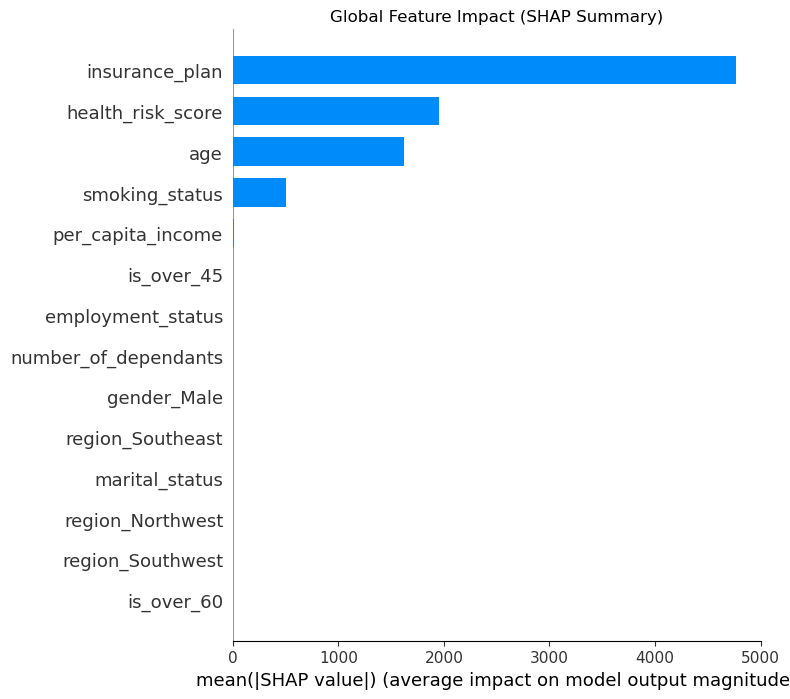

In [104]:
plt.figure(figsize=(10, 6))
plt.title("Global Feature Impact (SHAP Summary)")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

### Local Explainability ( SHAP ). Taking example of first person in test data (shap_values[0])

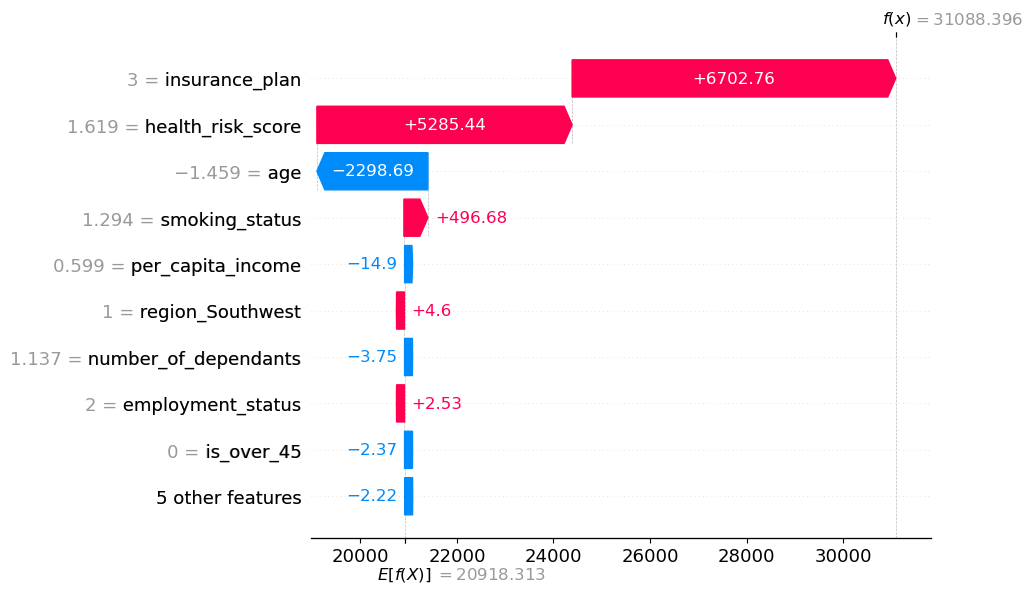

In [105]:
shap.plots.waterfall(shap_values[0])

### Making Pipeline to Deal with One Hot Encoding and Target Mean Encoding 

Odinal Encoding

In [106]:
ordinal_mappings = {
    'insurance_plan': {'Bronze': 1, 'Silver': 2, 'Gold': 3},
    'employment_status': {'Freelancer': 1, 'Salaried': 2, 'Self-Employed': 3}
}

Target Mean Encoding 

In [107]:
target_cols = ['medical_history', 'bmi_category', 'marital_status', 'smoking_status']
target_mean_mappings = {}

for col in target_cols:
    mean_dict = training_data.groupby(col)['annual_premium_amount'].mean().to_dict()
    target_mean_mappings[col] = mean_dict

Saving the Values

In [108]:
master_schema = {
    'ordinal': ordinal_mappings,
    'target_mean': target_mean_mappings
}
joblib.dump(master_schema, 'artifacts/senior_preprocessing_schema.joblib')

print("Data Saved")

Data Saved


### Saving the Scaler we used to use it in our pipeline 

In [109]:
joblib.dump(scaler, 'artifacts/scaler.joblib')
joblib.dump(scaling_cols, 'artifacts/senior_scaling_cols.joblib')

print("saved the scaler")

saved the scaler
